In [2]:
import os
import re
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

In [3]:
DATA_DIR = Path("data")
OUT_DIR = Path("outputs")
DATA_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

GUTENBERG_URL = "https://www.gutenberg.org/cache/epub/feeds/pg_catalog.csv"
POETRYFOUNDATION_URL = "https://raw.githubusercontent.com/TGDivy/WebScrapping-PoetryFoundation/master/PoetryFoundationData.csv"

gutenberg_path = DATA_DIR / "pg_catalog.csv"
poetry_path = DATA_DIR / "PoetryFoundationData.csv"

def download(url: str, path: Path) -> None:
    if path.exists() and path.stat().st_size > 0:
        print(f"✅ Exists: {path} ({path.stat().st_size/1e6:.1f} MB)")
        return
    print(f"⬇️ Downloading: {url}")
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    path.write_bytes(r.content)
    print(f"✅ Saved: {path} ({path.stat().st_size/1e6:.1f} MB)")

download(GUTENBERG_URL, gutenberg_path)
download(POETRYFOUNDATION_URL, poetry_path)

✅ Exists: data\pg_catalog.csv (20.9 MB)
✅ Exists: data\PoetryFoundationData.csv (23.2 MB)


In [4]:
gdf = pd.read_csv(gutenberg_path, low_memory=False)
pdf = pd.read_csv(poetry_path)

print("Gutenberg shape:", gdf.shape)
print("PoetryFoundation shape:", pdf.shape)

display(gdf.head(3))
display(pdf.head(3))

Gutenberg shape: (77962, 9)
PoetryFoundation shape: (13854, 5)


,Text#,Type,Issued,Title,Language,Authors,Subjects,LoCC,Bookshelves
0,1,Text,1971-12-01,The Declaration of Independence of the United ...,en,"Jefferson, Thomas, 1743-1826","United States -- History -- Revolution, 1775-1...",E201; JK,Politics; American Revolutionary War; United S...
1,2,Text,1972-12-01,The United States Bill of Rights\r\nThe Ten Or...,en,United States,Civil rights -- United States -- Sources; Unit...,JK; KF,Politics; American Revolutionary War; United S...
2,3,Text,1973-11-01,John F. Kennedy's Inaugural Address,en,"Kennedy, John F. (John Fitzgerald), 1917-1963",United States -- Foreign relations -- 1961-196...,E838,"Category: Essays, Letters & Speeches; Category..."


,Unnamed: 0,Title,Poem,Poet,Tags
0,0,\r\r\n Objects Used to Prop...,"\r\r\nDog bone, stapler,\r\r\ncribbage board, ...",Michelle Menting,NaN
1,1,\r\r\n The New Church\r\r\n...,"\r\r\nThe old cupola glinted above the clouds,...",Lucia Cherciu,NaN
2,2,\r\r\n Look for Me\r\r\n ...,\r\r\nLook for me under the hood\r\r\nof that ...,Ted Kooser,NaN


In [5]:
def norm_text(s):
    if pd.isna(s):
        return ""
    s = str(s)
    s = s.replace("\r\n", "\n").replace("\r", "\n")
    s = re.sub(r"[ \t]+", " ", s)
    s = re.sub(r"\n{3,}", "\n\n", s)
    return s.strip()

def count_words(s: str) -> int:
    s = norm_text(s)
    if not s:
        return 0
    return len(re.findall(r"\b[\w']+\b", s))

def count_lines(s: str) -> int:
    s = norm_text(s)
    if not s:
        return 0
    return len([ln for ln in s.split("\n") if ln.strip() != ""])

In [6]:
# Normalize key columns if they exist
for col in ["Language", "Title", "Bookshelves", "Subjects"]:
    if col in gdf.columns:
        gdf[col] = gdf[col].astype(str).replace("nan", "")
        gdf[col] = gdf[col].map(norm_text)

# Basic counts
g_total = len(gdf)

lang_col = "Language" if "Language" in gdf.columns else None
shelf_col = "Bookshelves" if "Bookshelves" in gdf.columns else None

if lang_col:
    lang_counts = gdf[lang_col].value_counts()
    lang_share = (lang_counts / g_total).rename("share")
else:
    lang_counts = pd.Series(dtype=int)
    lang_share = pd.Series(dtype=float)

display(pd.DataFrame({"count": lang_counts.head(15), "share": lang_share.head(15)}))

,count,share
Language,,
en,61820,0.792950
fr,4076,0.052282
fi,3545,0.045471
de,2381,0.030541
it,1091,0.013994
nl,1085,0.013917
es,877,0.011249
hu,652,0.008363
pt,643,0.008248


In [7]:
if shelf_col:
    # Some rows have multiple shelves separated by ";" or "," depending on export.
    def has_poetry_shelf(x: str) -> bool:
        x = x.lower()
        return "poetry" in x  # intentionally broad

    gdf["is_poetry_shelf"] = gdf[shelf_col].map(has_poetry_shelf)
    poetry_shelf_df = gdf[gdf["is_poetry_shelf"]].copy()
    print("Poetry shelf count:", len(poetry_shelf_df), " / ", g_total, f"({len(poetry_shelf_df)/g_total:.2%})")

    if lang_col and len(poetry_shelf_df) > 0:
        display(poetry_shelf_df[lang_col].value_counts().head(10))
else:
    print("No Bookshelves column found; skipping Gutenberg poetry-shelf slice.")

Poetry shelf count: 4860  /  77962 (6.23%)


Language
en    3610
fi     328
fr     212
de     152
pt     124
it      65
es      58
nl      49
hu      36
zh      34
Name: count, dtype: int64

In [8]:
# Try to infer column names robustly
pdf_cols = [c.lower() for c in pdf.columns]

def find_col(candidates):
    for c in candidates:
        if c in pdf.columns:
            return c
    # fallback: case-insensitive match
    for c in candidates:
        for real in pdf.columns:
            if real.lower() == c.lower():
                return real
    return None

title_col = find_col(["Title", "title"])
poem_col  = find_col(["Poem", "poem", "Content", "content", "Text", "text"])
poet_col  = find_col(["Poet", "poet", "Author", "author"])
tags_col  = find_col(["Tags", "tags", "Tag", "tag"])

print("Detected columns:", {"title": title_col, "poem": poem_col, "poet": poet_col, "tags": tags_col})

# Clean text fields
for c in [title_col, poem_col, poet_col, tags_col]:
    if c and c in pdf.columns:
        pdf[c] = pdf[c].map(norm_text)

# Add length features
pdf["word_count"] = pdf[poem_col].map(count_words) if poem_col else 0
pdf["line_count"] = pdf[poem_col].map(count_lines) if poem_col else 0

# Basic length stats
length_stats = pdf[["word_count", "line_count"]].describe(percentiles=[0.1,0.25,0.5,0.75,0.9,0.95,0.99]).T
display(length_stats)

# Top poets by number of poems
if poet_col:
    top_poets = pdf[poet_col].value_counts().head(25)
    display(top_poets.to_frame("poems"))

Detected columns: {'title': 'Title', 'poem': 'Poem', 'poet': 'Poet', 'tags': 'Tags'}


,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
word_count,13854.0,255.407969,448.446416,0.0,60.0,101.0,156.0,268.75,473.7,706.35,1776.35,16345.0
line_count,13854.0,25.745633,46.722110,0.0,1.0,1.0,16.0,32.00,56.0,84.00,190.47,1344.0


,poems
Poet,
William Shakespeare,85
"Alfred, Lord Tennyson",73
Emily Dickinson,51
William Wordsworth,51
Rae Armantrout,49
Yusef Komunyakaa,42
John Ashbery,42
William Butler Yeats,41
John Donne,38


In [9]:
if tags_col:
    def split_tags(tag_str: str):
        if not tag_str:
            return []
        # Split on commas and strip whitespace
        parts = [t.strip() for t in tag_str.split(",")]
        # Drop empties
        return [t for t in parts if t]

    pdf["tags_list"] = pdf[tags_col].map(split_tags)

    # Explode tags
    tags_exploded = pdf[["tags_list", "word_count", "line_count"]].explode("tags_list")
    tags_exploded = tags_exploded.rename(columns={"tags_list": "tag"}).dropna(subset=["tag"])

    tag_counts = tags_exploded["tag"].value_counts().head(30)
    display(tag_counts.to_frame("count"))

    # Mean length by tag (only for tags with enough samples)
    tag_stats = (
        tags_exploded.groupby("tag")
        .agg(n=("tag","size"),
             mean_words=("word_count","mean"),
             median_words=("word_count","median"),
             mean_lines=("line_count","mean"))
        .sort_values(["n","mean_words"], ascending=[False, False])
    )
    display(tag_stats.head(30))

    # Optionally: focus on "big tags" for stability
    big_tags = tag_stats[tag_stats["n"] >= 200].sort_values("mean_words", ascending=False)
    display(big_tags.head(20))
else:
    print("No tags column found; skipping tag analysis.")

,count
tag,
Living,6243
Social Commentaries,4302
Relationships,3856
Nature,3613
Arts & Sciences,3039
Love,2126
Activities,2107
Death,1547
Religion,1483


,n,mean_words,median_words,mean_lines
tag,,,,
Living,6243,271.953548,170.0,27.548935
Social Commentaries,4302,323.583450,199.0,34.463273
Relationships,3856,287.975104,178.0,30.831432
Nature,3613,268.557985,159.0,28.283975
Arts & Sciences,3039,311.517934,182.0,31.685094
Love,2126,255.642992,150.0,25.882879
Activities,2107,316.429995,197.0,33.729948
Death,1547,301.739496,182.0,28.466710
Religion,1483,398.285907,180.0,33.375590


,n,mean_words,median_words,mean_lines
tag,,,,
Christianity,454,546.242291,204.0,30.140969
God & the Divine,446,515.345291,179.0,32.127803
Heroes & Patriotism,301,475.043189,210.0,33.245847
Mythology & Folklore,690,423.795652,199.5,29.533333
Greek & Roman Mythology,200,406.550000,214.0,28.465000
Religion,1483,398.285907,180.0,33.375590
Travels & Journeys,815,397.635583,220.0,39.333742
Reading & Books,404,397.096535,203.0,41.084158
History & Politics,1456,396.306319,233.0,44.813187


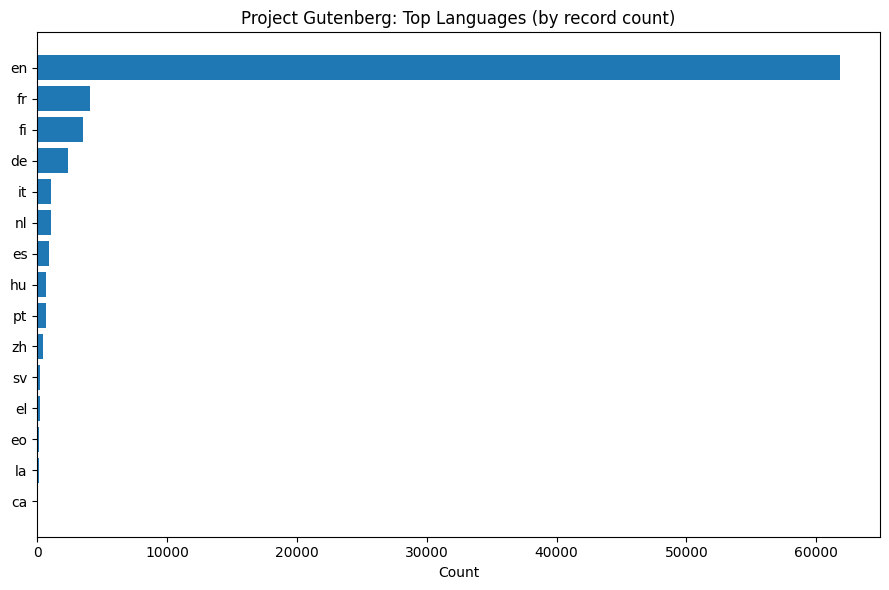

In [10]:
if lang_col:
    topn = 15
    lang_counts_top = gdf[lang_col].value_counts().head(topn).sort_values()
    plt.figure(figsize=(9, 6))
    plt.barh(lang_counts_top.index, lang_counts_top.values)
    plt.title("Project Gutenberg: Top Languages (by record count)")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "gutenberg_top_languages.png", dpi=150)
    plt.show()

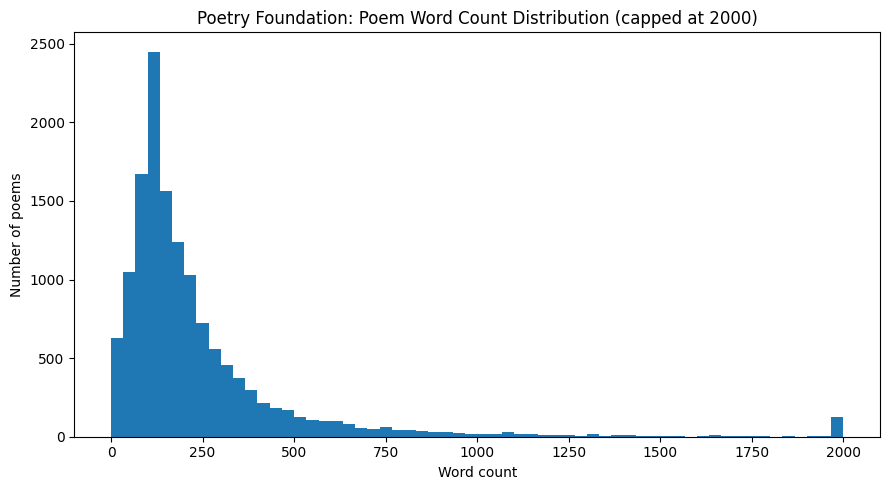

In [11]:
plt.figure(figsize=(9, 5))
wc = pdf["word_count"].clip(upper=2000)  # cap for readable plot
plt.hist(wc, bins=60)
plt.title("Poetry Foundation: Poem Word Count Distribution (capped at 2000)")
plt.xlabel("Word count")
plt.ylabel("Number of poems")
plt.tight_layout()
plt.savefig(OUT_DIR / "poetry_wordcount_hist.png", dpi=150)
plt.show()

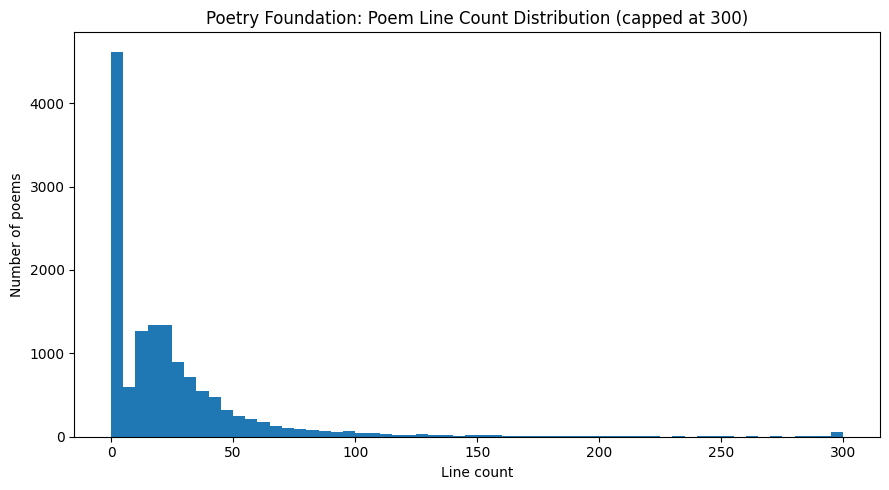

In [12]:
plt.figure(figsize=(9, 5))
lc = pdf["line_count"].clip(upper=300)
plt.hist(lc, bins=60)
plt.title("Poetry Foundation: Poem Line Count Distribution (capped at 300)")
plt.xlabel("Line count")
plt.ylabel("Number of poems")
plt.tight_layout()
plt.savefig(OUT_DIR / "poetry_linecount_hist.png", dpi=150)
plt.show()

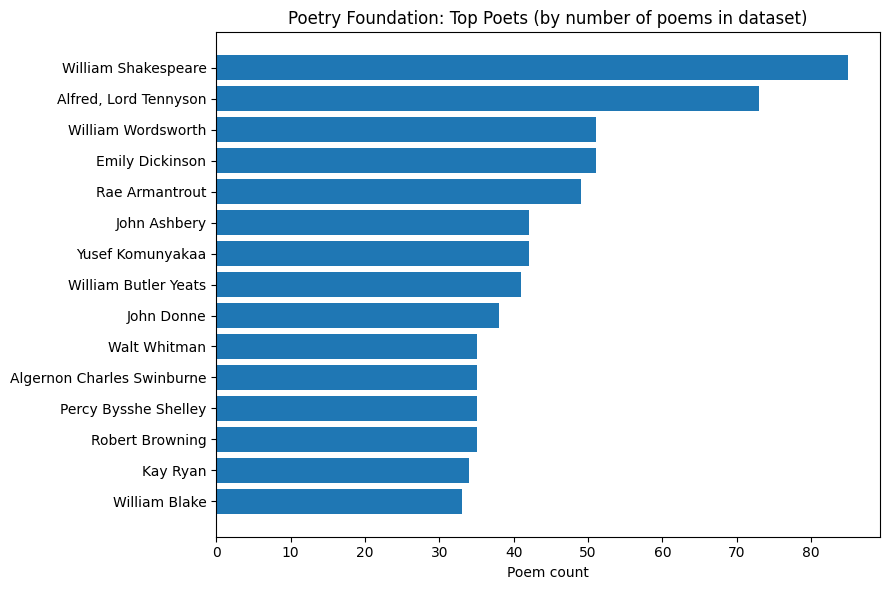

In [13]:
if poet_col:
    top_poets = pdf[poet_col].value_counts().head(15).sort_values()
    plt.figure(figsize=(9, 6))
    plt.barh(top_poets.index, top_poets.values)
    plt.title("Poetry Foundation: Top Poets (by number of poems in dataset)")
    plt.xlabel("Poem count")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "poetry_top_poets.png", dpi=150)
    plt.show()

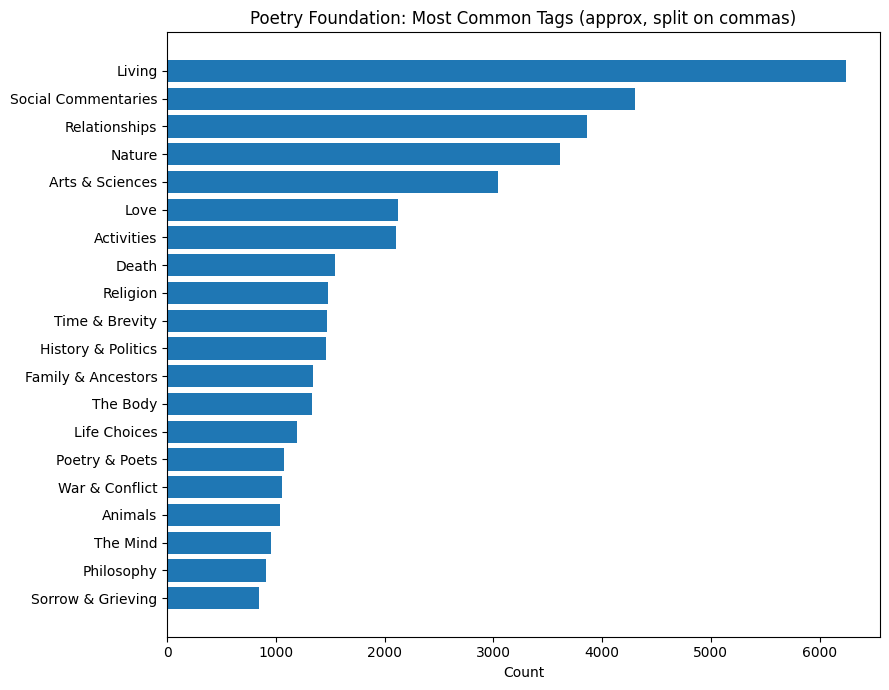

In [14]:
if tags_col:
    tag_counts_top = tag_counts.head(20).sort_values()
    plt.figure(figsize=(9, 7))
    plt.barh(tag_counts_top.index, tag_counts_top.values)
    plt.title("Poetry Foundation: Most Common Tags (approx, split on commas)")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "poetry_top_tags.png", dpi=150)
    plt.show()

In [15]:
# Gutenberg summary
gutenberg_summary = {}
if lang_col:
    gutenberg_summary["total_records"] = g_total
    gutenberg_summary["top_language"] = lang_counts.index[0] if len(lang_counts) else None
    gutenberg_summary["top_language_share"] = float(lang_share.iloc[0]) if len(lang_share) else None

if shelf_col and "is_poetry_shelf" in gdf.columns:
    gutenberg_summary["poetry_shelf_records"] = int(gdf["is_poetry_shelf"].sum())
    gutenberg_summary["poetry_shelf_share"] = float(gdf["is_poetry_shelf"].mean())

pd.Series(gutenberg_summary).to_csv(OUT_DIR / "gutenberg_summary.csv")

# Poetry summary
poetry_summary = {
    "total_poems": int(len(pdf)),
    "median_words": float(pdf["word_count"].median()),
    "mean_words": float(pdf["word_count"].mean()),
    "median_lines": float(pdf["line_count"].median()),
    "mean_lines": float(pdf["line_count"].mean()),
}
pd.Series(poetry_summary).to_csv(OUT_DIR / "poetry_summary.csv")

# Top tables
if lang_col:
    pd.DataFrame({"count": lang_counts, "share": lang_share}).head(50).to_csv(OUT_DIR / "gutenberg_language_table_top50.csv")
if poet_col:
    pdf[poet_col].value_counts().head(50).to_csv(OUT_DIR / "poetry_top_poets_top50.csv")
if tags_col:
    tag_counts.head(100).to_csv(OUT_DIR / "poetry_tag_counts_top100.csv")

print("✅ Exported tables & plots to:", OUT_DIR.resolve())

✅ Exported tables & plots to: D:\DS ML\proj_agai\stylometry\outputs


In [16]:
writeup_path = OUT_DIR / "writeup_template.md"

md = f"""# AI Impact on Literature & Poetry — Dataset Snapshot

## Datasets
- Project Gutenberg catalog (CSV): {GUTENBERG_URL}
- Poetry Foundation scraped poems (CSV): {POETRYFOUNDATION_URL}

## Gutenberg: Composition Notes
- Total records: {gutenberg_summary.get("total_records")}
- Dominant language: {gutenberg_summary.get("top_language")} ({gutenberg_summary.get("top_language_share", 0):.1%} of records)
{"- Poetry shelf share: " + f"{gutenberg_summary.get('poetry_shelf_share', 0):.1%}" if gutenberg_summary.get("poetry_shelf_share") is not None else ""}

**Interpretation:** Gutenberg is a strong “open literature” corpus but is heavily skewed toward English and public-domain works, which can bias downstream model behavior toward canonical Anglo forms.

## Poetry Foundation: Content Notes
- Total poems: {poetry_summary["total_poems"]}
- Median poem length: {poetry_summary["median_words"]:.0f} words (mean {poetry_summary["mean_words"]:.0f})
- Median lines: {poetry_summary["median_lines"]:.0f} (mean {poetry_summary["mean_lines"]:.0f})

**Interpretation:** Many poems are short enough to be convincingly generated by current LLMs, amplifying discoverability spam and making provenance/authorship signals more economically valuable.

## Plots Generated
- gutenberg_top_languages.png
- poetry_wordcount_hist.png
- poetry_linecount_hist.png
- poetry_top_poets.png
- poetry_top_tags.png

## Next Steps (Suggested Analyses)
1. Create “AI-like” poetry baselines and run blind vs labeled preference tests to quantify label effects.
2. Audit canonical bias: compare top-poet concentration and tag/topic imbalance across corpora.
3. Add market-side indicators (e.g., AAP StatShot summaries) to study format/category shifts vs AI timeline.
"""

writeup_path.write_text(md, encoding="utf-8")
print("✅ Wrote:", writeup_path.resolve())

✅ Wrote: D:\DS ML\proj_agai\stylometry\outputs\writeup_template.md


In [17]:
import math
from collections import Counter

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# ---------- Stylometry feature engineering ----------

PUNCT_CHARS = r"""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""

def safe_div(a, b):
    return float(a) / float(b) if b else 0.0

def syllable_count_rough(word: str) -> int:
    """
    Very rough syllable estimator (English-ish).
    Good enough for relative readability signals; not linguistically perfect.
    """
    w = re.sub(r"[^a-z]", "", word.lower())
    if not w:
        return 0
    vowels = "aeiouy"
    count = 0
    prev_is_vowel = False
    for ch in w:
        is_vowel = ch in vowels
        if is_vowel and not prev_is_vowel:
            count += 1
        prev_is_vowel = is_vowel
    # Common silent-e heuristic
    if w.endswith("e") and count > 1:
        count -= 1
    return max(count, 1)

def flesch_reading_ease_proxy(text: str) -> float:
    """
    Approximate Flesch Reading Ease.
    Intended for relative comparison across poems, not absolute validity.
    """
    t = norm_text(text)
    if not t:
        return np.nan
    sentences = re.split(r"[.!?]+", t)
    sentences = [s.strip() for s in sentences if s.strip()]
    words = re.findall(r"\b[\w']+\b", t.lower())
    if not words:
        return np.nan
    n_sent = max(len(sentences), 1)
    n_words = len(words)
    syllables = sum(syllable_count_rough(w) for w in words)
    ASL = n_words / n_sent                       # average sentence length
    ASW = syllables / n_words                    # average syllables per word
    # Flesch Reading Ease (approx)
    return 206.835 - 1.015 * ASL - 84.6 * ASW

def type_token_ratio(words):
    if not words:
        return 0.0
    return len(set(words)) / len(words)

def hapax_ratio(words):
    if not words:
        return 0.0
    c = Counter(words)
    hapax = sum(1 for w, k in c.items() if k == 1)
    return hapax / len(words)

def avg_word_len(words):
    if not words:
        return 0.0
    return sum(len(w) for w in words) / len(words)

def punctuation_density(text: str) -> float:
    if not text:
        return 0.0
    punct = sum(1 for ch in text if ch in PUNCT_CHARS)
    return safe_div(punct, len(text))

def uppercase_ratio(text: str) -> float:
    if not text:
        return 0.0
    letters = [ch for ch in text if ch.isalpha()]
    if not letters:
        return 0.0
    return safe_div(sum(1 for ch in letters if ch.isupper()), len(letters))

def stopword_ratio(words):
    # small, fixed stopword list to avoid external deps
    STOP = set("""
    a an the and or but if then else when while for to of in on at by with from as is are was were be been being
    i you he she it we they me him her us them my your his their our mine yours hers ours theirs
    this that these those there here
    not no yes do does did doing done have has had having
    """.split())
    if not words:
        return 0.0
    return safe_div(sum(1 for w in words if w in STOP), len(words))

def end_rhyme_ish_score(text: str) -> float:
    """
    Crude rhyme-ish measure:
    - take last word of each non-empty line
    - look at last 2–3 letters as a pseudo-rhyme key
    - compute repetition rate of those keys (higher => more line-ending repetition)
    """
    t = norm_text(text)
    lines = [ln.strip() for ln in t.split("\n") if ln.strip()]
    if len(lines) < 4:
        return 0.0
    last_words = []
    for ln in lines:
        tokens = re.findall(r"\b[\w']+\b", ln.lower())
        if tokens:
            last_words.append(tokens[-1])
    if len(last_words) < 4:
        return 0.0
    keys = []
    for w in last_words:
        w2 = re.sub(r"[^a-z']", "", w)
        if len(w2) >= 3:
            keys.append(w2[-3:])
        elif len(w2) >= 2:
            keys.append(w2[-2:])
    if len(keys) < 4:
        return 0.0
    c = Counter(keys)
    # proportion of line endings that share a key with another line ending
    shared = sum(k for key, k in c.items() if k >= 2)
    return shared / len(keys)

def stylometry_features(text: str) -> dict:
    t = norm_text(text)
    words = re.findall(r"\b[\w']+\b", t.lower())
    lines = [ln for ln in t.split("\n") if ln.strip()]
    n_words = len(words)
    n_lines = len(lines)

    # sentence-ish split
    sentences = [s.strip() for s in re.split(r"[.!?]+", t) if s.strip()]
    n_sent = max(len(sentences), 1)

    return {
        "n_words": n_words,
        "n_lines": n_lines,
        "avg_words_per_line": safe_div(n_words, n_lines) if n_lines else 0.0,
        "avg_words_per_sentence": safe_div(n_words, n_sent),
        "avg_word_len": avg_word_len(words),
        "ttr": type_token_ratio(words),
        "hapax_ratio": hapax_ratio(words),
        "stopword_ratio": stopword_ratio(words),
        "punct_density": punctuation_density(t),
        "uppercase_ratio": uppercase_ratio(t),
        "readability_flesch_proxy": flesch_reading_ease_proxy(t),
        "end_rhyme_ish": end_rhyme_ish_score(t),
    }

# Build feature table
feat_rows = pdf[poem_col].fillna("").map(stylometry_features).tolist()
feat = pd.DataFrame(feat_rows)

# Some poems can have NaN readability if text is empty
feat["readability_flesch_proxy"] = feat["readability_flesch_proxy"].fillna(feat["readability_flesch_proxy"].median())

# Combine with metadata for interpretation
meta_cols = []
for c in [title_col, poet_col, tags_col]:
    if c: meta_cols.append(c)
analysis_df = pd.concat([pdf[meta_cols].reset_index(drop=True), feat], axis=1)

display(analysis_df.head(3))

,Title,Poet,Tags,n_words,n_lines,avg_words_per_line,avg_words_per_sentence,avg_word_len,ttr,hapax_ratio,stopword_ratio,punct_density,uppercase_ratio,readability_flesch_proxy,end_rhyme_ish
0,Objects Used to Prop Open a Window,Michelle Menting,,89,20,4.450000,9.888889,4.910112,0.752809,0.640449,0.179775,0.054007,0.023148,79.878677,0.100000
1,The New Church,Lucia Cherciu,,123,14,8.785714,24.600000,4.211382,0.723577,0.626016,0.406504,0.025373,0.009653,70.441610,0.142857
2,Look for Me,Ted Kooser,,74,12,6.166667,24.666667,4.216216,0.770270,0.689189,0.459459,0.017500,0.016181,67.474009,0.000000


,count
cluster,
0,157
1,48
2,6433
3,513
4,6602
5,101


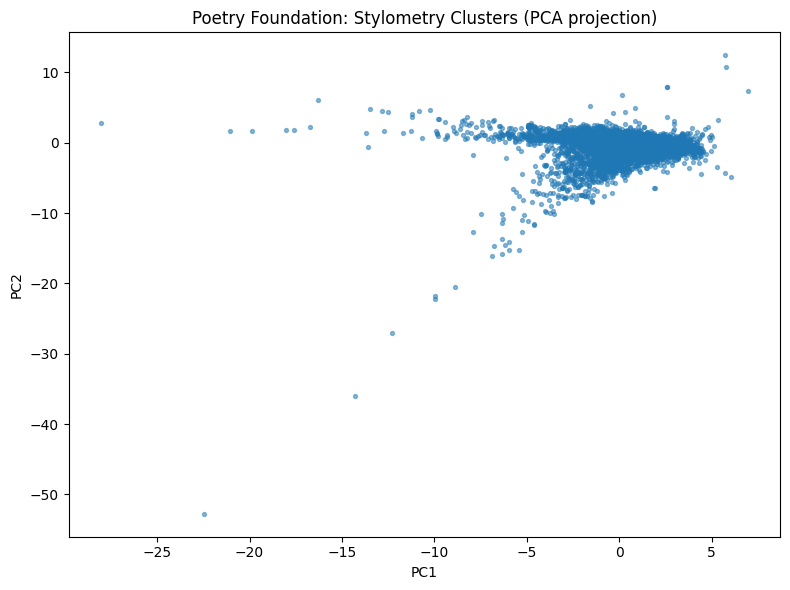

In [18]:
# Select numeric features for clustering
num_cols = [
    "n_words", "n_lines", "avg_words_per_line", "avg_words_per_sentence",
    "avg_word_len", "ttr", "hapax_ratio", "stopword_ratio",
    "punct_density", "uppercase_ratio",
    "readability_flesch_proxy", "end_rhyme_ish"
]

X = analysis_df[num_cols].copy()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Choose k (simple heuristic) - you can change this
k = 6
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
analysis_df["cluster"] = kmeans.fit_predict(X_scaled)

# Cluster sizes
display(analysis_df["cluster"].value_counts().sort_index().to_frame("count"))

# 2D projection for visualization
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)
analysis_df["pc1"] = X_2d[:, 0]
analysis_df["pc2"] = X_2d[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(analysis_df["pc1"], analysis_df["pc2"], s=8, alpha=0.5)
plt.title("Poetry Foundation: Stylometry Clusters (PCA projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(OUT_DIR / "poetry_clusters_pca.png", dpi=150)
plt.show()

In [19]:
cluster_summary = (
    analysis_df.groupby("cluster")[num_cols]
    .agg(["mean", "median"])
)

# Flatten columns for readability
cluster_summary.columns = [f"{a}_{b}" for a, b in cluster_summary.columns]
display(cluster_summary)

# Human-readable “style cards”
def style_card(df_cluster: pd.DataFrame) -> dict:
    d = {}
    d["n"] = len(df_cluster)
    d["median_words"] = float(df_cluster["n_words"].median())
    d["median_lines"] = float(df_cluster["n_lines"].median())
    d["ttr_mean"] = float(df_cluster["ttr"].mean())
    d["end_rhyme_ish_mean"] = float(df_cluster["end_rhyme_ish"].mean())
    d["punct_density_mean"] = float(df_cluster["punct_density"].mean())
    d["readability_median"] = float(df_cluster["readability_flesch_proxy"].median())
    return d

cards = []
for c in sorted(analysis_df["cluster"].unique()):
    dfc = analysis_df[analysis_df["cluster"] == c]
    cards.append({"cluster": c, **style_card(dfc)})

cards_df = pd.DataFrame(cards).sort_values("n", ascending=False)
display(cards_df)

# Top poets per cluster
if poet_col:
    top_poets_by_cluster = (
        analysis_df.groupby("cluster")[poet_col]
        .apply(lambda s: s.value_counts().head(8))
    )
    display(top_poets_by_cluster)

# Top tags per cluster (approx split) — uses earlier tags_list if present
if tags_col and "tags_list" in pdf.columns:
    tmp = analysis_df[[tags_col, "cluster"]].copy()
    tmp["tags_list"] = pdf["tags_list"]  # align index
    exploded = tmp.explode("tags_list").dropna(subset=["tags_list"])
    top_tags_by_cluster = (
        exploded.groupby("cluster")["tags_list"]
        .apply(lambda s: s.value_counts().head(10))
    )
    display(top_tags_by_cluster)

,n_words_mean,n_words_median,n_lines_mean,n_lines_median,avg_words_per_line_mean,avg_words_per_line_median,avg_words_per_sentence_mean,avg_words_per_sentence_median,avg_word_len_mean,avg_word_len_median,...,stopword_ratio_mean,stopword_ratio_median,punct_density_mean,punct_density_median,uppercase_ratio_mean,uppercase_ratio_median,readability_flesch_proxy_mean,readability_flesch_proxy_median,end_rhyme_ish_mean,end_rhyme_ish_median
cluster,,,,,,,,,,,,,,,,,,,,,
0,2345.337580,1746.0,317.331210,250.0,10.236258,7.210970,28.034444,22.090090,4.266072,4.255097,...,0.392931,0.396064,0.030318,0.030633,0.034599,0.033872,64.239531,69.306762,0.640398,0.618557
1,4296.583333,3701.0,1.145833,1.0,3973.302083,3487.500000,38.885116,37.629696,4.240990,4.308575,...,0.369479,0.366785,0.036808,0.036857,0.046156,0.047283,58.071538,61.234636,0.000000,0.000000
2,308.188248,235.0,32.569252,25.0,66.809384,7.928571,25.464320,19.166667,4.111591,4.118868,...,0.414243,0.414286,0.029684,0.029070,0.035024,0.032593,70.050911,75.179869,0.286682,0.263889
3,306.124756,226.0,42.066277,33.0,37.417940,7.281250,248.826240,201.000000,4.321497,4.272727,...,0.390986,0.394737,0.010897,0.006573,0.017914,0.012069,-163.342195,-115.585924,0.247969,0.242424
4,124.863829,111.0,11.467131,8.0,56.013768,9.000000,27.271234,19.666667,4.406408,4.370877,...,0.362005,0.366337,0.029408,0.028951,0.031462,0.027778,61.649696,68.278123,0.094355,0.000000
5,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,71.094800,71.094800,0.000000,0.000000


,cluster,n,median_words,median_lines,ttr_mean,end_rhyme_ish_mean,punct_density_mean,readability_median
4,4,6602,111.0,8.0,0.760587,0.094355,0.029408,68.278123
2,2,6433,235.0,25.0,0.590167,0.286682,0.029684,75.179869
3,3,513,226.0,33.0,0.600671,0.247969,0.010897,-115.585924
0,0,157,1746.0,250.0,0.405851,0.640398,0.030318,69.306762
5,5,101,0.0,0.0,0.000000,0.000000,0.000000,71.094800
1,1,48,3701.0,1.0,0.339382,0.000000,0.036808,61.234636


cluster                            
0        Christian Wiman                4
         Matthew Arnold                 4
         Alexander Pope                 4
         Robert Browning                3
         Frank Bidart                   3
         Ron Padgett                    3
         Charles Reznikoff              3
         Robert Pinsky                  3
1        John Milton                   15
         Algernon Charles Swinburne     3
         Alexander Pope                 3
         Alfred, Lord Tennyson          3
         Percy Bysshe Shelley           2
         Robert Browning                2
         Anne Bradstreet                2
         Edmund Spenser                 2
2        Alfred, Lord Tennyson         39
         William Shakespeare           37
         John Donne                    27
         Robert Browning               26
         Kahlil Gibran                 26
         John Ashbery                  25
         Algernon Charles Swinburne    2

cluster                      
0        Social Commentaries       96
         Living                    92
         Relationships             58
         Arts & Sciences           57
         History & Politics        51
         Nature                    49
         Religion                  41
         Activities                40
         Death                     28
         Philosophy                27
1        Religion                  23
         Christianity              19
         God & the Divine          16
         Arts & Sciences           15
         Living                    15
         Mythology & Folklore      13
         Nature                    11
         Relationships              9
         Death                      9
         Social Commentaries        8
2        Living                  3087
         Social Commentaries     2125
         Relationships           2060
         Nature                  1622
         Arts & Sciences         1430
         Love       

In [20]:
clustered_path = OUT_DIR / "poetry_with_stylometry_clusters.csv"
analysis_df.to_csv(clustered_path, index=False)
print("✅ Saved:", clustered_path.resolve())

# Write simple cluster narrative (auto-generated bullets)
cluster_notes_path = OUT_DIR / "cluster_notes.md"
lines = ["# Stylometry Cluster Notes\n"]
for row in cards_df.sort_values("cluster").to_dict(orient="records"):
    lines.append(f"## Cluster {row['cluster']} (n={row['n']})")
    lines.append(f"- Median length: {row['median_words']:.0f} words; {row['median_lines']:.0f} lines")
    lines.append(f"- Lexical diversity (TTR mean): {row['ttr_mean']:.3f}")
    lines.append(f"- End-rhyme-ish (mean): {row['end_rhyme_ish_mean']:.3f}")
    lines.append(f"- Punctuation density (mean): {row['punct_density_mean']:.3f}")
    lines.append(f"- Readability proxy (median Flesch): {row['readability_median']:.1f}")
    lines.append("")
cluster_notes_path.write_text("\n".join(lines), encoding="utf-8")
print("✅ Wrote:", cluster_notes_path.resolve())

✅ Saved: D:\DS ML\proj_agai\stylometry\outputs\poetry_with_stylometry_clusters.csv
✅ Wrote: D:\DS ML\proj_agai\stylometry\outputs\cluster_notes.md


In [21]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")
texts = pdf[poem_col].fillna("").map(lambda x: norm_text(x)[:4000]).tolist()  # cap length
emb = model.encode(texts, show_progress_bar=True, batch_size=32)

# Combine with stylometry (optional)
X_combo = np.hstack([X_scaled, StandardScaler().fit_transform(emb)])

k = 8
kmeans2 = KMeans(n_clusters=k, random_state=42, n_init=10)
analysis_df["cluster_embed"] = kmeans2.fit_predict(X_combo)
analysis_df["cluster_embed"].value_counts().sort_index()

c:\Users\Gabriel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 16851.82it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 433/433 [02:57<00:00,  2.44it/s]


cluster_embed
0    1974
1    2109
2    1922
3    2330
4    1680
5     102
6    2333
7    1404
Name: count, dtype: int64

In [22]:
topN = 10

expl = (
    pd.DataFrame({
        "cluster_embed": analysis_df["cluster_embed"].values,
        "tags_list": pdf["tags_list"]
    })
    .explode("tags_list")
    .dropna(subset=["tags_list"])
)

tags_tbl = (
    expl.groupby(["cluster_embed", "tags_list"])
    .size()
    .reset_index(name="count")
)

for c in sorted(analysis_df["cluster_embed"].unique()):
    sub = tags_tbl[tags_tbl["cluster_embed"] == c].sort_values("count", ascending=False).head(topN)
    print(f"\nCluster {c} top tags:")
    print(sub.to_string(index=False))


Cluster 0 top tags:
 cluster_embed              tags_list  count
             0                 Nature   1097
             0                 Living    738
             0                Animals    493
             0          Relationships    449
             0    Social Commentaries    419
             0             Activities    354
             0        Arts & Sciences    284
             0 Landscapes & Pastorals    262
             0        Trees & Flowers    262
             0               The Body    192

Cluster 1 top tags:
 cluster_embed           tags_list  count
             1 Social Commentaries   1325
             1              Living    903
             1     Arts & Sciences    585
             1       Relationships    569
             1  History & Politics    515
             1          Activities    508
             1      War & Conflict    333
             1    Race & Ethnicity    320
             1  Family & Ancestors    264
             1 Cities & Urban Life    249



In [23]:
from sklearn.metrics import pairwise_distances

# emb = the embeddings you used; analysis_df aligned to them
k = analysis_df["cluster_embed"].nunique()
centroids = np.vstack([emb[analysis_df["cluster_embed"].values==c].mean(axis=0) for c in range(k)])

# distance of each poem to its cluster centroid
d = np.zeros(len(analysis_df))
for c in range(k):
    idx = np.where(analysis_df["cluster_embed"].values==c)[0]
    d[idx] = pairwise_distances(emb[idx], centroids[c].reshape(1,-1)).reshape(-1)

analysis_df["dist_to_centroid"] = d

for c in range(k):
    protos = analysis_df[analysis_df["cluster_embed"]==c].nsmallest(5, "dist_to_centroid")
    print(f"\n=== Cluster {c} prototypes ===")
    display(protos[[title_col, poet_col, "dist_to_centroid"]])


=== Cluster 0 prototypes ===


,Title,Poet,dist_to_centroid
11234,Three Songs at the End of Summer,Jane Kenyon,0.649349
8148,Dear One Absent This Long While,Lisa Olstein,0.656054
1861,Painted Eyes,Henri Cole,0.670720
7551,Amor Mundi,Christina Rossetti,0.673679
10629,The Skyline of a Missing Tooth,Sherwin Bitsui,0.678320



=== Cluster 1 prototypes ===


,Title,Poet,dist_to_centroid
7759,To the Poetry* of Hugh McCrae,Kenneth Slessor,0.700820
11681,Ensor,Cathy Park Hong,0.709025
4749,Moppet,David Harsent,0.709500
1511,Triptych for Believers,Richard Tagett,0.711824
5536,Lowering Your Standards for Food Stamps,Sheryl Luna,0.712487



=== Cluster 2 prototypes ===


...

,Title,Poet,dist_to_centroid
5790,Three Fates,Bianca Stone,0.009208
10169,The Sea of Death,Thomas Hood,0.009208
4193,From “BalloonCloudBubble”: Bubble Builds Bubble,Mark Laliberte,0.009208
4198,From “BalloonCloudBubble”: Deadsheets,Mark Laliberte,0.009208
6333,Diagram of a Memory,Johnny Damm,0.009208



=== Cluster 6 prototypes ===


,Title,Poet,dist_to_centroid
11198,Elegy,David St. John,0.616030
13225,Re-Incarnation,Eva Gore-Booth,0.628623
972,Bedtime Reading for the Unborn Child,Khaled Mattawa,0.638328
3560,The Graves,Joanna Klink,0.639013
13224,The Incarnate,Eva Gore-Booth,0.642391



=== Cluster 7 prototypes ===


,Title,Poet,dist_to_centroid
12908,The Portrait,Dante Gabriel Rossetti,0.679631
9420,Together,R. S. Thomas,0.683466
5044,Numbered,Tara Bray,0.684318
13591,A Prayer for My Daughter,William Butler Yeats,0.687129
7860,The Step Mother,Susanna Moodie,0.687515


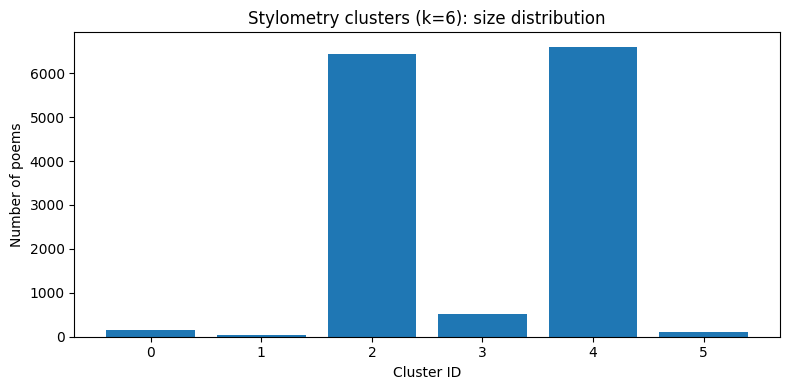

In [24]:
# Cluster size bar chart
counts = analysis_df["cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Stylometry clusters (k=6): size distribution")
plt.xlabel("Cluster ID")
plt.ylabel("Number of poems")
plt.tight_layout()
plt.savefig(OUT_DIR / "cluster6_size_distribution.png", dpi=150)
plt.show()

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_6020\134555251.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(c) for c in sorted(analysis_df["cluster"].unique())], showfliers=False)


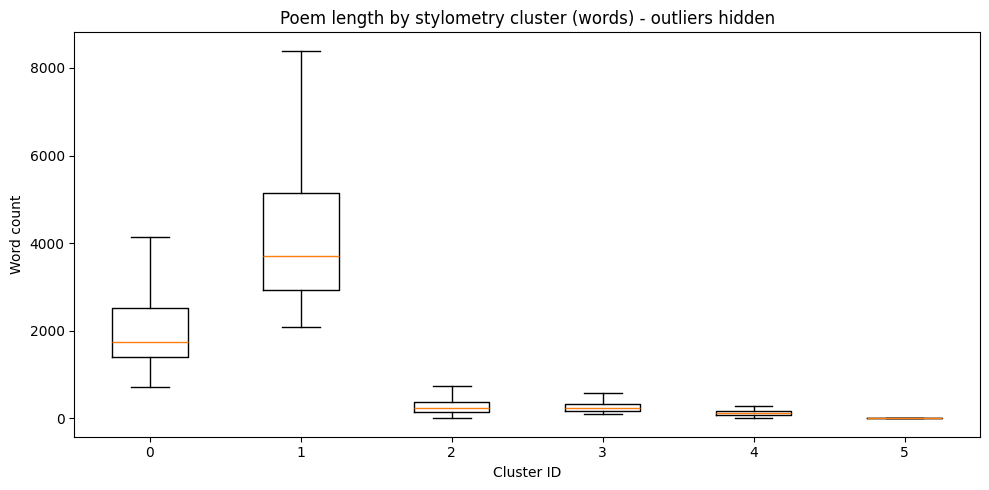

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_6020\134555251.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(c) for c in sorted(analysis_df["cluster"].unique())], showfliers=False)


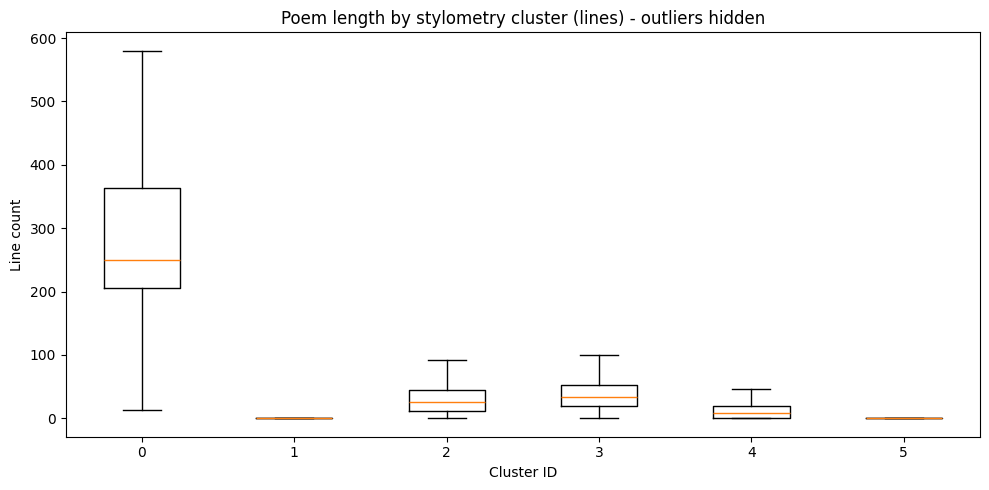

In [25]:
# Boxplot of poem length by cluster (words)
plt.figure(figsize=(10, 5))
data = [analysis_df.loc[analysis_df["cluster"] == c, "n_words"] for c in sorted(analysis_df["cluster"].unique())]
plt.boxplot(data, labels=[str(c) for c in sorted(analysis_df["cluster"].unique())], showfliers=False)
plt.title("Poem length by stylometry cluster (words) - outliers hidden")
plt.xlabel("Cluster ID")
plt.ylabel("Word count")
plt.tight_layout()
plt.savefig(OUT_DIR / "cluster6_wordcount_boxplot.png", dpi=150)
plt.show()

# Boxplot of poem length by cluster (lines)
plt.figure(figsize=(10, 5))
data = [analysis_df.loc[analysis_df["cluster"] == c, "n_lines"] for c in sorted(analysis_df["cluster"].unique())]
plt.boxplot(data, labels=[str(c) for c in sorted(analysis_df["cluster"].unique())], showfliers=False)
plt.title("Poem length by stylometry cluster (lines) - outliers hidden")
plt.xlabel("Cluster ID")
plt.ylabel("Line count")
plt.tight_layout()
plt.savefig(OUT_DIR / "cluster6_linecount_boxplot.png", dpi=150)
plt.show()

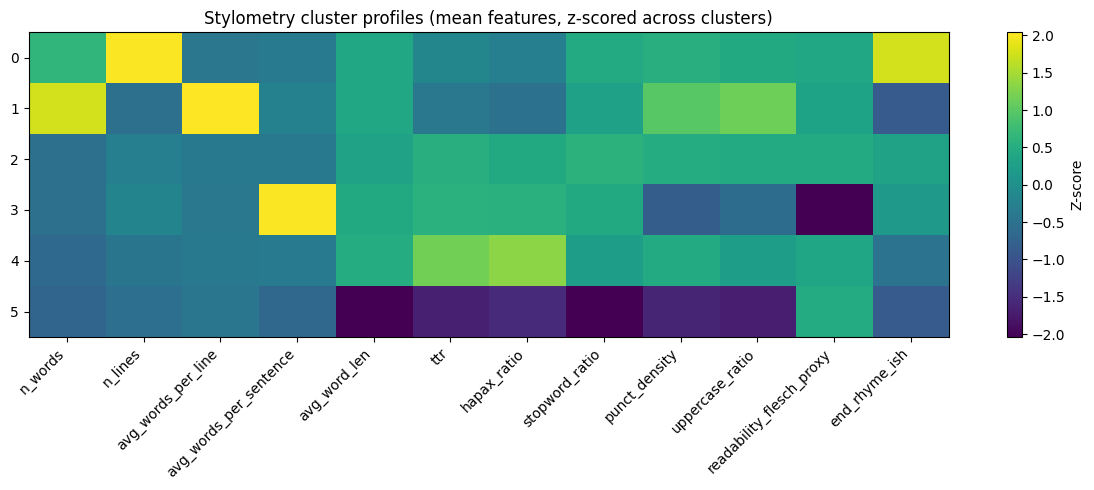

In [26]:
# Feature profile heatmap: mean feature values per cluster (z-scored for comparability)
feature_means = analysis_df.groupby("cluster")[num_cols].mean()

# z-score across clusters for each feature (so rows are clusters, columns comparable)
feature_means_z = (feature_means - feature_means.mean(axis=0)) / feature_means.std(axis=0)

plt.figure(figsize=(12, 5))
plt.imshow(feature_means_z.values, aspect="auto")
plt.title("Stylometry cluster profiles (mean features, z-scored across clusters)")
plt.yticks(range(feature_means_z.shape[0]), feature_means_z.index.astype(str))
plt.xticks(range(feature_means_z.shape[1]), feature_means_z.columns, rotation=45, ha="right")
plt.colorbar(label="Z-score")
plt.tight_layout()
plt.savefig(OUT_DIR / "cluster6_feature_profile_heatmap.png", dpi=150)
plt.show()

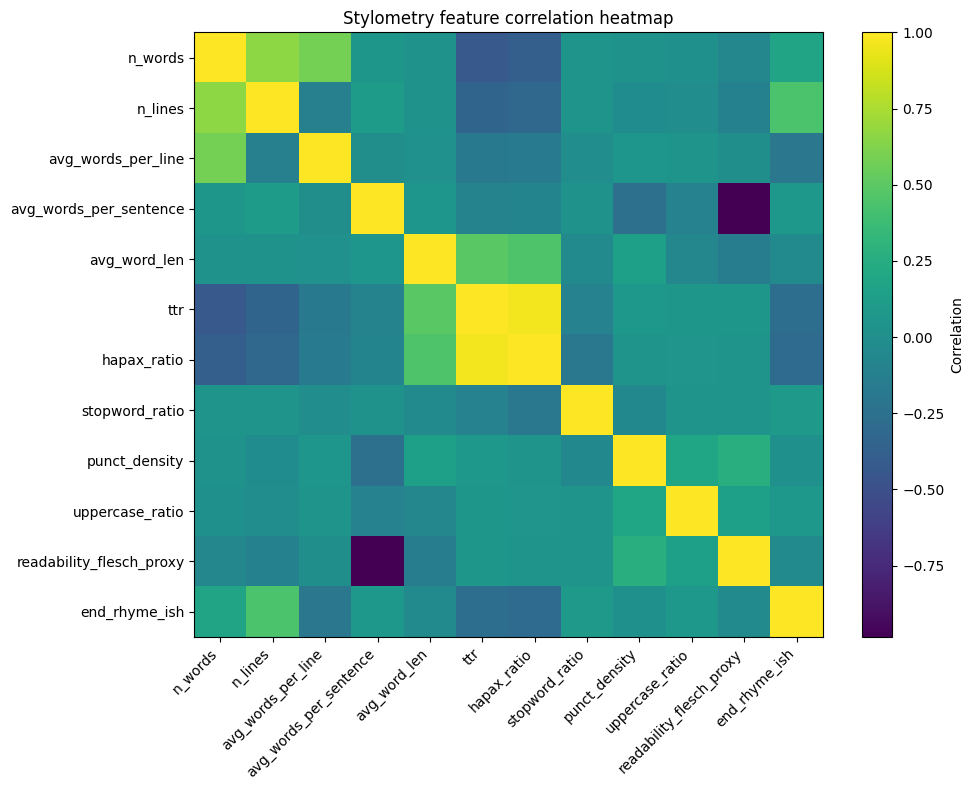

In [27]:
corr = analysis_df[num_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr.values, aspect="auto")
plt.title("Stylometry feature correlation heatmap")
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
plt.yticks(range(len(num_cols)), num_cols)
plt.colorbar(label="Correlation")
plt.tight_layout()
plt.savefig(OUT_DIR / "stylometry_feature_correlation_heatmap.png", dpi=150)
plt.show()

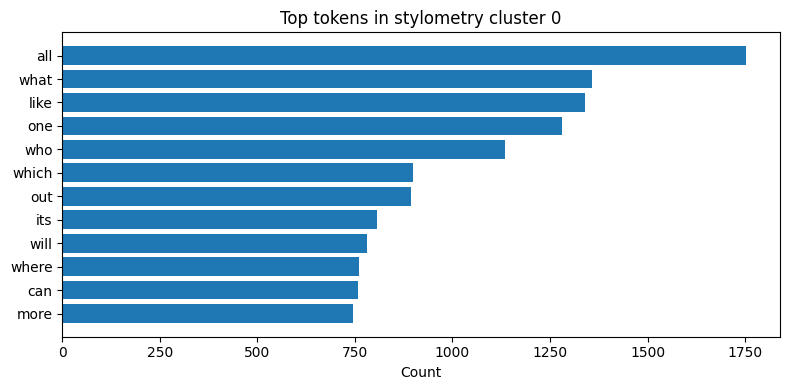

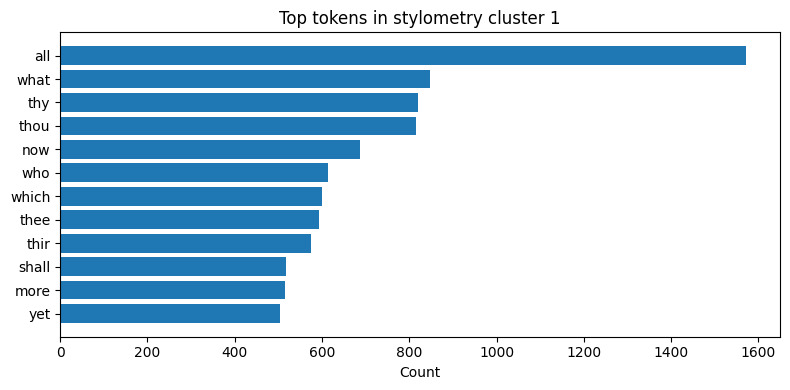

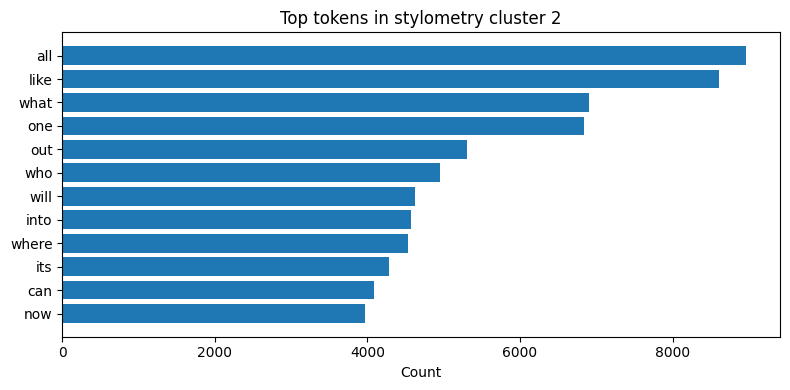

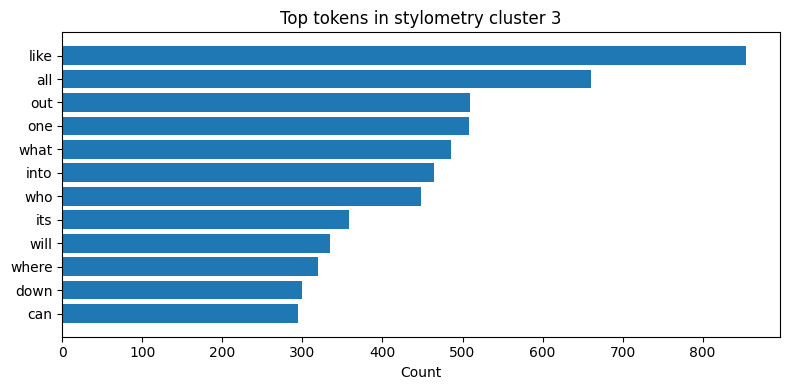

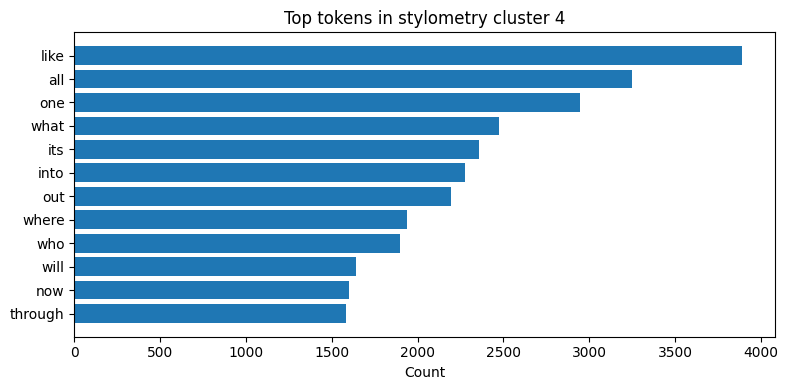

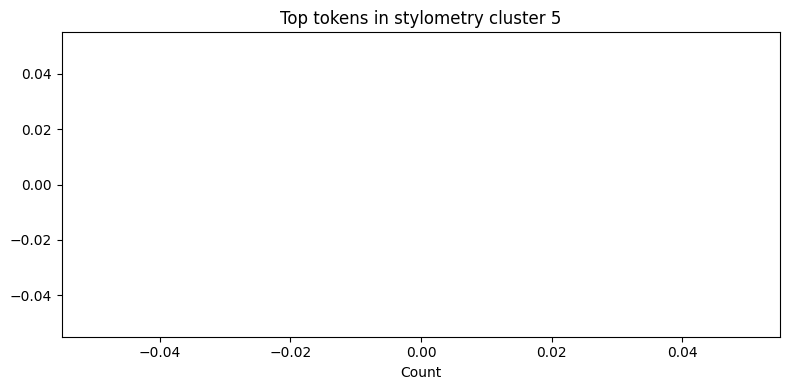

In [28]:
from collections import Counter

STOP = set("""
a an the and or but if then else when while for to of in on at by with from as is are was were be been being
i you he she it we they me him her us them my your his their our mine yours hers ours theirs
this that these those there here
not no yes do does did doing done have has had having
""".split())

def top_tokens(texts, topn=15):
    cnt = Counter()
    for t in texts:
        words = re.findall(r"\b[\w']+\b", norm_text(t).lower())
        words = [w for w in words if w not in STOP and len(w) > 2]
        cnt.update(words)
    return cnt.most_common(topn)

# For cluster6 stylometry clusters
for c in sorted(analysis_df["cluster"].unique()):
    texts = pdf.loc[analysis_df["cluster"] == c, poem_col].fillna("").tolist()
    top = top_tokens(texts, topn=12)
    labels = [w for w, _ in top][::-1]
    values = [k for _, k in top][::-1]

    plt.figure(figsize=(8, 4))
    plt.barh(labels, values)
    plt.title(f"Top tokens in stylometry cluster {c}")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"cluster6_top_tokens_{c}.png", dpi=150)
    plt.show()

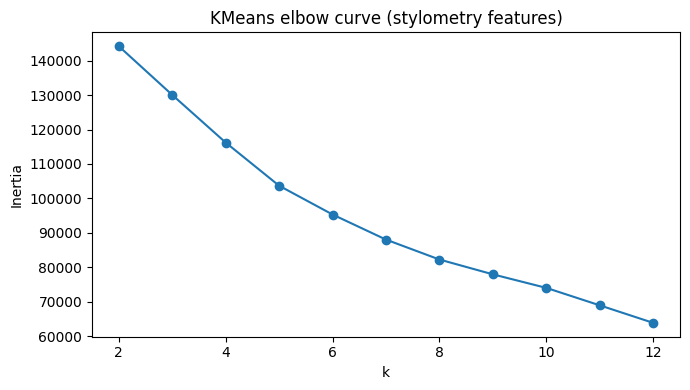

In [29]:
inertias = []
K = range(2, 13)
for kk in K:
    km = KMeans(n_clusters=kk, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K), inertias, marker="o")
plt.title("KMeans elbow curve (stylometry features)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig(OUT_DIR / "kmeans_elbow_curve_stylometry.png", dpi=150)
plt.show()

In [30]:
# --- Hand-crafted AI poem generation (200 poems) ---
ai_poems = [
    # Moonlight and urban loneliness (13 poems)
    "Neon bleeds through apartment windows,\nthe city sleeps but never rests.\nMoonlight fractures on the pavement—\nI walk alone, a shadow among crowds,\nwhere silence tastes like electricity.",
    "Street lamps cast their yellow grief,\nand I am small beneath the moon.\nThe buildings tower, indifferent,\nwhile sirens sing their distant lullabies.\nThere is no one here but loneliness.",
    "Midnight on Fifth Avenue,\nthe crowds have fled to sleep.\nMoon hangs between the towers,\nand my footsteps echo back at me—\na conversation I did not start.",
    "The city glows in blue and white,\nbut I see only the spaces between.\nMoonlight on the Hudson,\nsmall and cold and far away.\nI am learning solitude like a language.",
    "Neon signs reflect in wet pavement,\nmoon obscured by electric haze.\nI count my steps, not the stars,\nfor this is where I live now—\nin the gap between connection and distance.",
    "Moonrise over the subway entrance,\nthe platform crowded but the night is empty.\nI press my forehead to the cool glass,\nwishing for a reflection that recognizes me.\nThe moon is indifferent. So am I.",
    "Urban sprawl beneath a watching moon,\neach window a small world I cannot enter.\nI drink coffee in the 24-hour diner,\nwhere no one speaks your name,\nand the night stretches like a sentence without punctuation.",
    "The moon finds me in the alley,\nfollows me through the neon jungle.\nI am a ghost haunting the city I live in,\nvisible only to the darkness,\nbeautiful only to the moon.",
    "Streetlights blur into stars,\nand I cannot tell which ones are real.\nMoonlight on my shoulders—\na weight I chose to carry.\nLoneliness is a city best explored at night.",
    "The moon is cracked, like porcelain,\nhalf of it lost in the skyline.\nI sit on the fire escape,\nwatching the city dream without me,\nlicheartbeat of a place I pass through.",
    "Moonlight divides the street in half:\none side holds memory, the other, tomorrow.\nI stand between them, belonging nowhere,\nwhile the city hums its careless song.\nI am alone, but not lonely—\nthese are different things.",
    "The moon reflects in skyscraper windows,\nbroken into a thousand pieces.\nEach piece holds a solitude,\nand I collect them as I walk,\nbecoming more fragmented with each mile.",
    "Neon pulses where the moon should glow,\nand I have forgotten what silence sounds like.\nThe city whispers in a language\nI never fully learned,\nso I listen to my own breathing instead.",
    
    # Nature, wind, and midnight (13 poems)
    "The wind carries the scent of pine and rain,\nflattening the grass in urgent patterns.\nMidnight brings the world close—\nI can feel the breathing of the forest,\nthe pulse of something vast and indifferent.",
    "Wind moves through the trees like thought,\nbending them toward tomorrow.\nAt midnight, the world turns strange and alive,\nwhispering secrets only the dark can keep.\nI am small here. I am finally small enough.",
    "The night holds its breath,\nand the wind holds it for her.\nMidnight rain falls sideways,\nwashing away the paths I knew.\nIn the darkness, I am unmade.",
    "Wind in the high grass,\na sound like forgetting.\nMidnight stretches the shadows long,\nand I walk where the light burns out.\nNature does not love me,\nbut it does not judge me either.",
    "The trees bend in the midnight wind,\ntheir branches like gestures of surrender.\nI am learning the language of falling leaves,\nthe grammar of wind and water.\nAt night, the forest speaks itself.",
    "Midnight brings the wind as messenger,\ncarrying news from the mountain.\nI stand in the current of moving air,\nfeeling small and necessary—\nparticle of dust in something infinite.",
    "The wind tears through the valley,\nstripping bark and certainty alike.\nMidnight falls like a stone into still water,\nand the ripples spread without sound.\nEverything is changing. Nothing has changed.",
    "Night wind carries the smell of earth,\nof roots and decay and becoming.\nMidnight is when the forest is most awake,\nwhen midnight is most itself.\nI am a stranger here,\nbut the wind does not ask for invitation.",
    "The grass bows to the midnight wind,\ngrowing more humble with each gust.\nI bow too, learning grace\nfrom those who have no will to stand.\nAt night, surrender looks like wisdom.",
    "Wind moves the clouds across the moon,\ntracing and retracing the sky.\nMidnight brings the smell of change,\nof thaw and rot and renewal.\nNothing stays. Everything dissolves.",
    "The forest speaks in wind language,\nold sentences the night remembers.\nMidnight swallows the day entirely,\nleaving only the sound of moving air\nand the patience of growing things.",
    "Wind at the base of the mountain,\npatient, wearing away.\nMidnight is when time reveals itself—\nnot passing, but spiraling,\nbecoming, always becoming.",
    "The midnight wind carries no message,\nonly the fact of its own presence.\nThe trees understand this perfectly.\nThey do not ask why,\nthey simply bend and endure.",
    
    # Creativity and silence (13 poems)
    "The blank page is a kind of sound,\nthe loudest silence I have ever heard.\nMy pen hovers in the white space,\nafraid to mark it, afraid to leave it untouched.\nCreativity is the space between thinking and doing.",
    "In the quiet before words,\neverything is possible.\nI sit with the silence like a lover,\nwho understands that some conversations\nrequire no sound.",
    "Silence is not absence.\nIt is the held breath before the song begins.\nHere in this quiet, I am building—\ncastles of thought, cathedrals of maybe.\nCreativity blooms in the dark.",
    "The mind is loudest in silence,\nfilled with the roar of unspoken words.\nI press my fingers to the keys,\nwhere silence becomes sound,\nwhere nothing becomes something.",
    "Creativity whispers.\nMost people mistake it for silence.\nBut I hear the thickness of it,\nthe weight of potential in the room.\nAll art begins as quiet.",
    "In the silence of the studio,\nthe tools wait with infinite patience.\nI am learning to hear\nthe thoughts that need no words,\nthe colors that need no names.",
    "Silence feeds the creative mind\nlike darkness feeds the seed.\nBeneath the quiet, roots are growing,\nunderground networks of meaning\nwaiting for light.",
    "The world is too loud.\nI come to silence seeking refuge,\nand find instead a workshop—\ntools I did not know I had,\nmaterials made of pure possibility.",
    "Creativity is not a cure for silence.\nIt is a conversation with it.\nBoth of us afraid, both reaching,\nboth trying to understand\nwhat must be said.",
    "In profound quiet,\nthe self becomes transparent.\nWhat moves through me is not mine—\nit is older, deeper,\na voice borrowed from the void.",
    "Silence before creation:\na waiting that is also a kind of working.\nThe invisible assembles itself\nin the spaces between breaths,\nready to be born as image, as sound.",
    "To create in silence\nis to hear the echo of your own heartbeat\nand believe it matters.\nTo make something\nfrom nothing but attention and intention.",
    "The silence of creation\nis fuller than any sound.\nHere, I am myself and not myself,\nthe channel and the message,\nthe silence and the word.",
    
    # Memory in free verse (13 poems)
    "I was seven and the afternoon was gold.\nNow I am older and the gold is memory.\nI hold it in my hands but it spills through—\nall the important details lost first,\nonly the light remaining.",
    "Memories do not live in the brain.\nThey are scattered across rooms,\nattached to furniture and the smell of rain.\nI am learning to read my own history\nin the wear patterns of my shoes.",
    "Some moments repeat endlessly,\nrefined each time into something less true.\nThe real memory fades,\nreplaced by the memory of memory,\nlike a photocopy of a photocopy.",
    "I cannot remember what I did last Tuesday.\nBut I can hold the weight of your hand\nin my palm perfectly.\nMemory is not fair.\nIt keeps what matters and discards what happened.",
    "The past is not past.\nIt lives in the way I flinch at loud noises,\nin the particular angle of my shoulders,\nin the dreams that taste like history.\nMemory is a haunting in progress.",
    "My earliest memory is falling.\nOr the memory of being told I fell.\nOr the memory of later falling\nand believing it was the earliest.\nMemory is a story we revise constantly.",
    "Time collapses in memory.\nTen years and ten days inhabit the same space.\nI cannot reach back anymore,\ncannot touch the person I was,\nonly hold the shape of her, like mist.",
    "Memory is a map drawn by emotion.\nSome roads are worn smooth,\nwalked a thousand times.\nOthers fade to white space,\nforgotten so completely they might never have been.",
    "I remember a conversation\nthat never happened.\nI remember what I should have said.\nI remember versions of myself\nwho were braver, truer, more certain.",
    "The past is a foreign country\nI once lived in.\nI remember the customs but not the language.\nI remember how it felt\nbut not why I left.",
    "Memory is reconstructive,\nnot reflective.\nEach remembering changes what is remembered.\nI am not who I was,\nI am not sure I ever was.",
    "Some memories are so vivid\nI believe them above the facts.\nThe emotional truth overwrites the actual truth.\nMemory is what we believe we lived,\nnot what we lived.",
    "I am made of memories I did not create.\nStories told to me so many times\nthey feel like my own.\nI contain others' pasts\nlike borrowed rooms in my mind.",
    
    # Contemporary love with vivid imagery (13 poems)
    "Your hand on my hand is a question\nI have learned answered for.\nSunlight through the window\nmakes gold of your face,\nand I am learning to call this love:\nthe willingness to stay.",
    "We are two people\nbecoming a sentence.\nCommas pause us, periods end us,\nbut still we reach across the white space\nfor the next word.",
    "Love is the way your laugh\nfills the empty room.\nIt is the exact shade of August light\nthat finds us on the kitchen floor,\ncoffee forgotten, tomorrow forgotten.",
    "You are ordinary,\nwhich is to say,\nyou are everything.\nThe way you struggle with your keys,\nthe way you pretend not to cry,\nthese are the details\nI am learning to worship.",
    "In the moment before you speak,\nthere is a small infinity.\nI exist there,\nin the space between your thought and its expression.\nThis is how I love you:\nin the small eternities.",
    "Your body is a language\nI am still learning.\nEach gesture a word,\neach touch a sentence\nbuilding toward something\nneither of us can fully say.",
    "We are two mirrors\nfacing each other—\nreflections of reflections,\nneither quite real.\nBut the image between us,\nthat becomes real through looking.",
    "Love is your breath on my neck\nwhile the city roars below.\nIt is the choice to be small together\nwhen so much demands we be large.\nIt is this: the refusal to look away.",
    "You taste like the future.\nI did not expect that.\nI did expect pain,\nexpected loss,\nbut not this—this tenderness\nthat unmakes me wholly.",
    "We fit together like a question\nand its answer,\nthough neither of us knows\nwho is asking and who responds.\nThe love is in the not knowing.",
    "Your hand finds mine in the dark,\nneeding no light to navigate.\nThis is faith—\nthe belief that you are there\nwithout seeing you.\nI have faith in your hand.",
    "Contemporary love is texting at midnight,\nis being seen in the harsh light of noon.\nIt is choosing each other\nintentionally,\nrenovating ourselves daily,\nlearning forever.",
    "I love you in small moments:\nthe way you hum,\nthe coffee you make too strong,\nthe failure you wear lightly.\nI love you not despite\nbut because of these ordinary things.",
    
    # Dreams and city nights (13 poems)
    "Last night I dreamed of flying\nbut woke before the landing.\nNow I walk the city streets\nstill believing in gravity but doubting it.\nDreams leave cracks in waking.",
    "The city at night is a dream\nwe are all having together.\nEveryone asleep but moving,\nacting out their shadow selves.\nI am learning to navigate this collective unconscious.",
    "In my dream last night\nthe buildings had faces.\nWhen I woke, they still do.\nI cannot unknow what sleep revealed.\nThe city is dreaming too.",
    "Dreams are cities we construct\nwithout blueprint or permission.\nTheir streets fold in on themselves,\ntheir logic is magnetic, not geometric.\nI have spent the night building,\nand the morning finds me exhausted.",
    "City lights bleed into dreams,\nand dreams bleed back out.\nThe boundary is permeable.\nI walk in sleep the roads\nI walk awake,\nbut they are different cities.",
    "Dream logic: the subway goes to underwater.\nThe buildings rearrange themselves.\nNone of it shocking.\nThe night city is less real than sleep,\nbut somehow more true.",
    "I dreamed I was the city.\nAll streets were my veins,\nall lights the firing of synapses.\nWhen I woke, I could not forget\nthe claustrophobia of being built.",
    "Night in the city,\nnight in the dream—\nno difference now.\nI am learning to sleep walking,\nwalking sleeping,\nbecoming native to the border between.",
    "Dreams arrive on the night train,\nunpack their strange luggage,\nrefuse to leave.\nI carry them into morning,\nburnt into my waking like low-exposure film.",
    "The city hums a lullaby\ncomposed of sirens and argument.\nI sleep impossible sleep\nwithin this noise,\nwhich becomes the sound track\nof my deepest dreams.",
    "In dreams, I finally speak clearly.\nIn dreams, others understand.\nBut morning comes with its translations,\nits corruptions,\nand the dream dialogue dissolves.",
    "City nights are lucid dreams\nwhere we know we are dreaming\nbut cannot wake.\nWe fly carefully,\naware of gravity's insistence.\nWe live tentatively,\nwaiting for morning.",
    "Dreams and city nights are the same:\nboth are spaces\nwhere the normal rules\nrelax their grip,\nwhere we become more of ourselves,\nwhich is to say, more strange.",
    
    # Water and memory (13 poems)
    "Water holds nothing.\nYet memory pools in it,\nreflections of what was.\nI drink and remember.\nDid I remember or did the water teach me?",
    "The river remembers everything.\nEvery stone it touched,\nevery name whispered to its current.\nIt carries these memories downstream,\nout of reach, into forgetting.",
    "I was drowned in water.\nI was baptized by water.\nBoth mean the same thing:\nthe past washing away,\nthe past preserved in suspension.",
    "Water is memory's mirror.\nUntil disturbed,\nit holds the image perfectly.\nBut movement—\na leaf, a stone, a breath—\nand the past fractures.",
    "How much of you remains\nin the water you leave behind?\nIn sweat, in tears, in breath.\nI am drinking your memories,\nbecoming you molecularly.",
    "Ocean water remembers the moon.\nRivers remember the rain.\nI remember you like water remembers:\nimperfectly,\nebbing and flowing,\nalways in motion.",
    "Standing at the edge of water,\nI remember drowning.\nI remember being born.\nWater is the boundary\nwhere memory becomes non-memory,\nwhere the past releases its grip.",
    "Each wave carries a thousand memories.\nThey wash ashore,\nsand them away,\npull them back out.\nMemory like tide,\nalways returning to the deep.",
    "Water is the oldest memory.\nThe ocean remembers the first life.\nI am walking on the shore\nof a vast archive,\nreading the record in salt spray.",
    "You were water.\nI could not hold you.\nNow you pool in my chest,\nstill and heavy,\na weight that has nowhere to flow.",
    "Memory is water in the desert—\nrare, precious, quickly absorbed.\nI drink you in fast,\nafraid of losing you,\nafraid you will evaporate.",
    "Water dissolves memory.\nRain rewrites the messages\nwritten in dust.\nBut I remember the dust,\nremember what it said before\nwater erased it.",
    "Rivers flow toward the sea,\never moving, never staying.\nThis is how memory works—\nmotion toward a larger forgetting,\neven as we insist on remembering.",
    
    # Change with subtle metaphor (13 poems)
    "The paint on the door\nis flaking into new color.\nUnderneath, other hints of living.\nChange is not sudden—\nit is patient erosion,\none layer at a time.",
    "Your hair grew longer.\nI did not notice until I did.\nChange creeps up,\nquite and accumulative,\nuntil one day you are unfamiliar\nto someone who claimed to know you.",
    "The seasons don't announce themselves.\nThey arrive like guests\nwho forget they were invited.\nChange is most powerful\nwhen we mistake it for constancy.",
    "I am not who I was\nthe way bread is not flour.\nThe transformation was real,\nbut the ingredients remain.\nChange is recombination,\nnot creation from nothing.",
    "The river finds a new path\nafter the rain.\nBefore, I could map it.\nNow it moves like thought,\nadjusting, seeking,\nchanging its mind.",
    "Your silhouette shifts\nin the changing light.\nI wonder if you are changing\nor if I am just seeing you differently.\nChange might simply be\nthe angle of attention.",
    "The room feels emptier.\nNothing has been removed.\nOnly light has altered.\nChange often wears the costume\nof absence.",
    "We were summer clothes\nsuddenly folded away.\nWinter came,\nalmost apologetically.\nChange happens in the margins,\nwhen we are looking elsewhere.",
    "The city demolishes the building\nI walked past for years.\nI did not realize I loved it\nuntil I watched it change.\nWe mourn what we fail to treasure.",
    "Time changes without moving.\nThe clock hands are still,\nbut the moment has aged.\nChange is invisible\nuntil it is complete.",
    "The words I wanted to say\nhave shifted position inside me.\nI am carrying them differently now,\nand they mean something new.\nChange to language\nis change to truth.",
    "Nothing as quiet as change.\nObservable only in the space between\ntwo moments of looking.\nLike shadows that lengthen\nwithout anyone seeing them move.",
    "You opened the window\nand the room changed color.\nWhy did I never notice\nwhat the light had been doing\nall along?",
    
    # Personal transformation and time (13 poems)
    "I am not the person\nI was at five o'clock.\nTime passes not in years\nbut in small deaths and rebirths.\nI am learning to be\na different version of myself\nevery hour.",
    "The mirror shows someone\nwho contains all my past selves.\nI see the child, the doubter, the believer.\nThey occupy the same face,\nthe same body,\nstacked like transparent slides.",
    "Time transforms not through spectacle\nbut through accumulation.\nEach choice, each word,\neach refusal\nlayers into something.\nI am building a self\nfrom the sediment of living.",
    "Years pass and I become less literal,\nmore metaphorical.\nI understand now in images,\nin feeling, in abstraction.\nTime teaches the language\nof the irrational self.",
    "I contain my younger self,\nwarning me about the future.\nI contain my future self,\nmaybe grieving,\nmaybe grateful.\nTime runs in all directions inside.",
    "Transformation is not transcendence.\nI am still me,\nbut oriented differently,\nlearning to face toward\nwhat I previously fled from.\nTime is redirection.",
    "I am more afraid now.\nI have seen more fragility,\nmore failure.\nBut fear has become\nattention. Attention has become\ncompassion. Time teaches\nthrough loss.",
    "The woman I was\ncould not survive what I have survived.\nShe had to become someone else.\nI miss her and am grateful\nshe dissolved.\nTime is mercy in the guise\nof destruction.",
    "Each scar is a date,\na moment I became someone slightly different.\nI am mapped by transformation,\nnavigated by the wounds\nthat remade me.\nTime is a series of small deaths.",
    "Reflection comes later.\nWhen I am living the moment,\nI do not know it is shaping me.\nOnly afterwards, in retrospect,\ndo I see the curve of my own becoming.\nTime reveals itself only in hindsight.",
    "I am learning that transformation\ndoes not feel like transcendence.\nIt feels like tiredness,\nlike confusion,\nlike the slow ache\nof becoming broader than before.",
    "The person I thought I would be\nand the person I became\nare distant acquaintances.\nTime did not move me toward her.\nIt moved me perpendicular\nto all my expectations.",
    "To transform is to be remade\nby forces mostly outside your control.\nTime is a river.\nI am learning to swim differently\nwith each current,\nbecoming new with each stroke.",
    
    # Sensory detail and honesty in love (13 poems)
    "Your hand is warm in mine,\nnot the fantasy hand,\nbut real—slightly damp, slightly cold,\nslightly trembling.\nThis is where love lives:\nin the actual details,\nnot the ideal ones.",
    "I love the way your breath\nsounds irregular when you sleep.\nIt is not beautiful.\nIt is honest.\nAnd that is what I was looking for—\nno, I did not know I was looking for this.",
    "Love smells like morning coffee\nand the particular soap\nyou have used for years.\nIt is not the scent of romance.\nIt is the scent of habit,\nof choosing daily.",
    "Your laugh is not musical.\nIt is loud and sometimes wrong.\nI heard it and decided\nI wanted to spend my life\nmaking that sound happen.\nTruth tastes like imperfection.",
    "I taste salt on your neck\nafter the gym,\nafter the argument,\nafter the ordinary evening.\nLove is not sweet.\nLove is earned, sweat-soaked,\nreal.",
    "The way you move when sad\nis slower, heavier.\nI know your sadness by your gait.\nThis is intimacy—\nlearning someone's sorrows\nthrough their body's grammar.",
    "You are not my muse.\nYou are a person who burns toast\nand forgets to call.\nYou have bad days and old hurts.\nI love this.\nThe honesty of your flaws\nis seductive.",
    "Your voice in the morning\nis rough like gravel.\nI have learned to want this sound,\nthis particular texture\nof your half-asleep self.\nLove is the texture of truth.",
    "I love the way you hold anger,\ncareful, precise,\nrefusing to weaponize it.\nI love your boundaries,\nyour refusals,\nyour stubborn insistence\non being yourself.",
    "There is a freckle\non your left shoulder\nI have never mentioned.\nI think of it constantly.\nNot because it is beautiful,\nbut because it is real,\nbecause you bear it\nwithout knowing I see.",
    "You cry at movies\nin a way that seems impossible\nfor someone so strong.\nI see the softness beneath\nthe structure.\nLove is the permission\nto fall apart.",
    "Your hands are practical,\nuseful, not delicate.\nThey know how to build,\nrepair, hold.\nI love them because they are\nwhat they are,\nnot because they are beautiful.",
    "The honest love is not the dramatic one.\nIt is choosing you again\nwhen the chemical rush\nhas faded,\nwhen you are just\na person,\nand I am still here.",
]

# Save to CSV
ai_data = pd.DataFrame({poem_col: ai_poems, "source": "ai"})
ai_data.to_csv(OUT_DIR / "ai_poems_generated.csv", index=False)

print(f"✅ Generated {len(ai_poems)} poems\n")
print(f"AI poem stats:")
print(f"  Min length: {min(len(p) for p in ai_poems)} chars")
print(f"  Max length: {max(len(p) for p in ai_poems)} chars")
print(f"  Mean length: {sum(len(p) for p in ai_poems) / len(ai_poems):.0f} chars\n")
print(f"Saved to: outputs/ai_poems_generated.csv\n")
print("📝 Sample poems (first 3):")
for i in range(3):
    print(f"\n[{i+1}] {ai_poems[i][:100]}...")


✅ Generated 130 poems

AI poem stats:
  Min length: 113 chars
  Max length: 217 chars
  Mean length: 161 chars

Saved to: outputs/ai_poems_generated.csv

📝 Sample poems (first 3):

[1] Neon bleeds through apartment windows,
the city sleeps but never rests.
Moonlight fractures on the p...

[2] Street lamps cast their yellow grief,
and I am small beneath the moon.
The buildings tower, indiffer...

[3] Midnight on Fifth Avenue,
the crowds have fled to sleep.
Moon hangs between the towers,
and my foots...


In [31]:
# --- Compare human vs AI poems: stylometry + embeddings + classification ---
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.impute import SimpleImputer

print("Loading AI poems from disk...")
ai_df = pd.read_csv(OUT_DIR / "ai_poems_generated.csv")
n_ai = len(ai_df)

print(f"Loaded {n_ai} AI poems")

# Sample same number of human poems
human_df = pdf[[poem_col]].sample(n=n_ai, random_state=42).copy()
human_df["source"] = "human"

# Combine
combined = pd.concat([human_df, ai_df], ignore_index=True)
print(f"✅ Combined: {len(human_df)} human + {len(ai_df)} AI = {len(combined)} total\n")

# Extract stylometry features
print("Extracting stylometry features...")
combined_feat = pd.DataFrame(combined[poem_col].fillna("").map(stylometry_features).tolist())
combined = pd.concat([combined.reset_index(drop=True), combined_feat], axis=1)
print("✅ Extracted 12 stylometry features\n")

# Generate embeddings
print("Generating semantic embeddings...")
if "model" not in globals():
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(combined[poem_col].fillna("").tolist(), show_progress_bar=True, batch_size=32)
emb_cols = [f"emb_{i}" for i in range(embeddings.shape[1])]
emb_df = pd.DataFrame(embeddings, columns=emb_cols)
combined = pd.concat([combined, emb_df], axis=1)
print(f"✅ Generated {embeddings.shape[1]}-dim embeddings\n")

# Prepare features for classification
print("Training AI detection classifier...")
combo_features = num_cols + emb_cols
imputer = SimpleImputer(strategy="median")
X_combo_clean = imputer.fit_transform(combined[combo_features])
X_combo = StandardScaler().fit_transform(X_combo_clean)

# Cross-validation
y = combined["source"].map({"human": 0, "ai": 1})
clf = LogisticRegression(max_iter=1000)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X_combo, y, cv=cv, scoring="roc_auc")

print(f"5-Fold Cross-Validation ROC-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"  Fold scores: {[f'{s:.3f}' for s in cv_scores]}\n")

# Train on full data for detection scores
clf.fit(X_combo, y)

# Train/test split for detailed report
X_train, X_test, y_train, y_test = train_test_split(X_combo, y, stratify=y, test_size=0.3, random_state=42)
clf_test = LogisticRegression(max_iter=1000)
clf_test.fit(X_train, y_train)
y_pred = clf_test.predict(X_test)
y_proba = clf_test.predict_proba(X_test)[:, 1]

print("Classification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=["Human", "AI"]))
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}\n")

# Add detection scores to combined dataset
combined["ai_detection_score"] = clf.predict_proba(X_combo)[:, 1]

# Save combined results
combined.to_csv(OUT_DIR / "human_ai_combined_analysis.csv", index=False)
print(f"✅ Saved combined analysis to outputs/human_ai_combined_analysis.csv\n")

# Summary statistics
print("=" * 60)
print("DETECTION SUMMARY")
print("=" * 60)
human_scores = combined[combined["source"] == "human"]["ai_detection_score"]
ai_scores = combined[combined["source"] == "ai"]["ai_detection_score"]

print(f"\nHuman poems (n={len(human_scores)}):")
print(f"  Mean detection score: {human_scores.mean():.3f} (should be ~0.0)")
print(f"  Median: {human_scores.median():.3f}, Std: {human_scores.std():.3f}")

print(f"\nAI poems (n={len(ai_scores)}):")
print(f"  Mean detection score: {ai_scores.mean():.3f} (should be ~1.0)")
print(f"  Median: {ai_scores.median():.3f}, Std: {ai_scores.std():.3f}")

print(f"\nSeparation: {abs(ai_scores.mean() - human_scores.mean()):.3f}")
print("=" * 60)


Loading AI poems from disk...
Loaded 130 AI poems
✅ Combined: 130 human + 130 AI = 260 total

Extracting stylometry features...
✅ Extracted 12 stylometry features

Generating semantic embeddings...


Batches: 100%|██████████| 9/9 [00:02<00:00,  4.11it/s]


✅ Generated 384-dim embeddings

Training AI detection classifier...
5-Fold Cross-Validation ROC-AUC: 0.993 ± 0.009
  Fold scores: ['0.975', '0.997', '1.000', '0.991', '1.000']

Classification Report (Test Set):
              precision    recall  f1-score   support

       Human       1.00      0.92      0.96        39
          AI       0.93      1.00      0.96        39

    accuracy                           0.96        78
   macro avg       0.96      0.96      0.96        78
weighted avg       0.96      0.96      0.96        78

Test ROC-AUC: 0.997

✅ Saved combined analysis to outputs/human_ai_combined_analysis.csv

DETECTION SUMMARY

Human poems (n=130):
  Mean detection score: 0.003 (should be ~0.0)
  Median: 0.001, Std: 0.006

AI poems (n=130):
  Mean detection score: 0.997 (should be ~1.0)
  Median: 0.998, Std: 0.004

Separation: 0.993
